# Laboratorio 5: Minería de Textos y Análisis de Sentimiento
## Data Science - UVG 2026


##### Iris Ayala, Jonathan Díaz y Anggie Quezada

# PARTE 1: CARGA DE DATOS Y PREPROCESAMIENTO

## 1. Importar Librerías

In [8]:
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Cargar Datos

In [9]:
df = pd.read_csv('train.csv')

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nDesastres (1): {(df['target']==1).sum()}")
print(f"No desastres (0): {(df['target']==0).sum()}")
print(f"\nPrimeras filas:")
df.head()

Dataset cargado: 7613 filas, 5 columnas

Desastres (1): 3271
No desastres (0): 4342

Primeras filas:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 3. Exploración Inicial

In [10]:
print("INFORMACIÓN GENERAL")
print("=" * 60)
df.info()

print("\n\nVALORES NULOS")
print("=" * 60)
print(df.isnull().sum())

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


VALORES NULOS
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


## 4. Preprocesamiento de Texto

In [11]:
stop_words = set(stopwords.words('english'))

def limpiar_tweet(texto):
    """
    Limpia un tweet aplicando transformaciones:
    1. Minúsculas
    2. Quitar URLs
    3. Quitar menciones (@usuario)
    4. Quitar hashtags pero guardar palabra
    5. Quitar números
    6. Quitar puntuación
    7. Quitar espacios múltiples
    8. Quitar stopwords
    """
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'#', '', texto)
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^a-z\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    texto = ' '.join(palabras)
    
    return texto

print("Función de limpieza creada")

Función de limpieza creada


## 5. Aplicar Limpieza

In [12]:
print("Limpiando tweets...")
df['text_cleaned'] = df['text'].apply(limpiar_tweet)

print("Ejemplos ANTES y DESPUÉS:")
print("\nANTES:")
print(df['text'].iloc[0])
print("\nDESPUES:")
print(df['text_cleaned'].iloc[0])

# Quitar tweets vacíos
vacios = (df['text_cleaned'].str.len() == 0).sum()
if vacios > 0:
    df = df[df['text_cleaned'].str.len() > 0].reset_index(drop=True)
    print(f"\nTweets vacíos eliminados: {vacios}")

print(f"\nDataset final: {len(df)} tweets")

Limpiando tweets...
Ejemplos ANTES y DESPUÉS:

ANTES:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

DESPUES:
deeds reason earthquake may allah forgive us

Dataset final: 7613 tweets


## 6. Guardar Dataset Limpio

In [13]:
df.to_csv('train_cleaned.csv', index=False)
print("Dataset limpio guardado como 'train_cleaned.csv'")

Dataset limpio guardado como 'train_cleaned.csv'


---
# PARTE 2A: ANÁLISIS EXPLORATORIO Y FRECUENCIA DE PALABRAS

**Objetivo:** Analizar qué palabras aparecen más en desastres vs no-desastres y visualizar con nubes de palabras.

## 7. Importar Librerías Adicionales

In [14]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("Librerías de análisis importadas")

Librerías de análisis importadas


## 8. Calcular Frecuencia de Palabras

In [15]:
# Tweets de DESASTRES
tweets_desastres = df[df['target'] == 1]['text_cleaned']
texto_desastres = ' '.join(tweets_desastres.values)
palabras_desastres = texto_desastres.split()
frecuencia_desastres = Counter(palabras_desastres)
top_15_desastres = frecuencia_desastres.most_common(15)

print("TOP 15 PALABRAS EN TWEETS DE DESASTRES")
print("=" * 50)
for i, (palabra, freq) in enumerate(top_15_desastres, 1):
    print(f"{i:2}. {palabra:15} -> {freq:5} veces")

# Tweets de NO-DESASTRES
tweets_no_desastres = df[df['target'] == 0]['text_cleaned']
texto_no_desastres = ' '.join(tweets_no_desastres.values)
palabras_no_desastres = texto_no_desastres.split()
frecuencia_no_desastres = Counter(palabras_no_desastres)
top_15_no_desastres = frecuencia_no_desastres.most_common(15)

print("\n\nTOP 15 PALABRAS EN TWEETS DE NO-DESASTRES")
print("=" * 50)
for i, (palabra, freq) in enumerate(top_15_no_desastres, 1):
    print(f"{i:2}. {palabra:15} -> {freq:5} veces")

TOP 15 PALABRAS EN TWEETS DE DESASTRES
 1. fire            ->   180 veces
 2. news            ->   138 veces
 3. via             ->   121 veces
 4. disaster        ->   117 veces
 5. california      ->   111 veces
 6. suicide         ->   110 veces
 7. police          ->   107 veces
 8. amp             ->   107 veces
 9. people          ->   105 veces
10. killed          ->    93 veces
11. like            ->    92 veces
12. pm              ->    89 veces
13. hiroshima       ->    89 veces
14. fires           ->    85 veces
15. storm           ->    85 veces


TOP 15 PALABRAS EN TWEETS DE NO-DESASTRES
 1. like            ->   253 veces
 2. im              ->   248 veces
 3. amp             ->   193 veces
 4. new             ->   170 veces
 5. get             ->   163 veces
 6. dont            ->   154 veces
 7. one             ->   128 veces
 8. body            ->   113 veces
 9. via             ->    99 veces
10. would           ->    97 veces
11. video           ->    96 veces
12. lov

## 9. Gráfico Comparativo: Top 15 Palabras

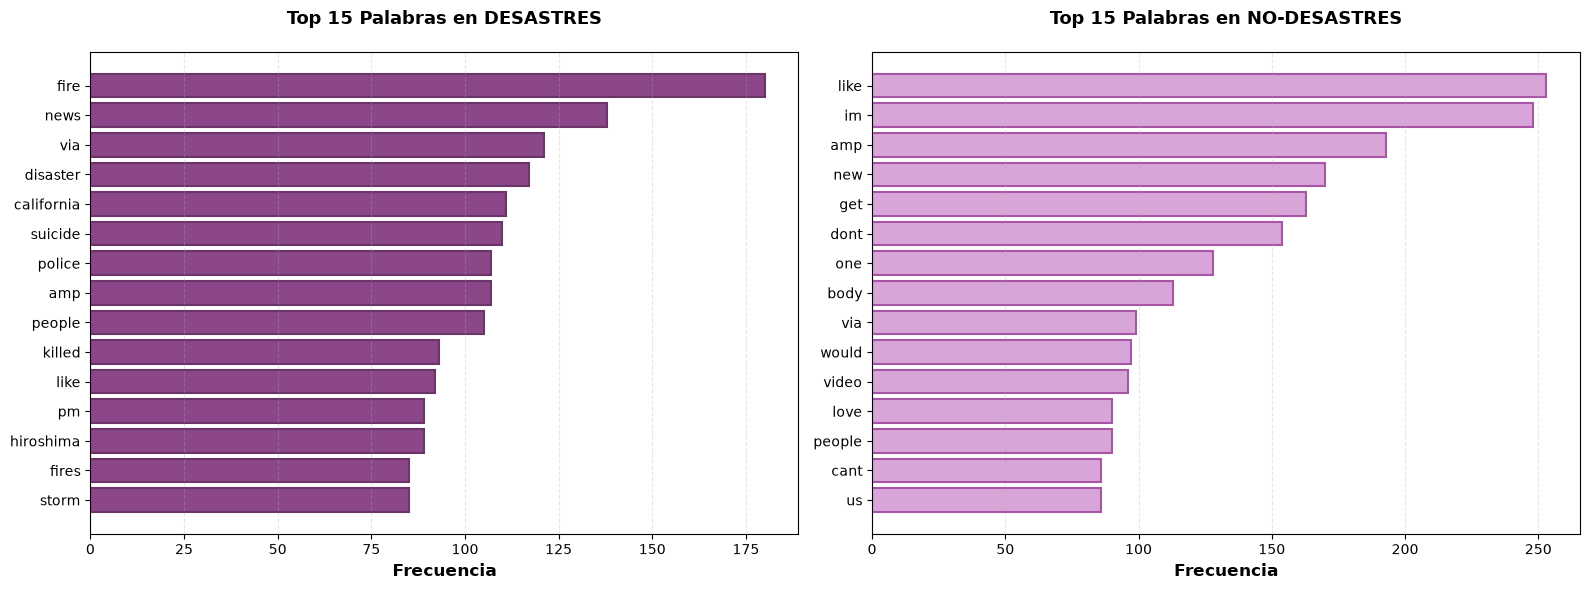

Gráfico guardado: frecuencia_palabras_comparacion.png


In [16]:
palabras_d = [p[0] for p in top_15_desastres]
freq_d = [p[1] for p in top_15_desastres]
palabras_nd = [p[0] for p in top_15_no_desastres]
freq_nd = [p[1] for p in top_15_no_desastres]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_desastres = '#8B4789'
color_no_desastres = '#D8A5D8'

axes[0].barh(palabras_d, freq_d, color=color_desastres, edgecolor='#6B3569', linewidth=1.5)
axes[0].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Palabras en DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

axes[1].barh(palabras_nd, freq_nd, color=color_no_desastres, edgecolor='#A855A8', linewidth=1.5)
axes[1].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Top 15 Palabras en NO-DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('frecuencia_palabras_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: frecuencia_palabras_comparacion.png")

## 10. Análisis de Palabras Discriminantes

In [17]:
print("\nPALABRAS QUE DISTINGUEN DESASTRES")
print("=" * 60)

ratios = {}
for palabra, freq_d in frecuencia_desastres.most_common(200):
    freq_nd = frecuencia_no_desastres.get(palabra, 1)
    ratio = freq_d / freq_nd
    ratios[palabra] = {'desastres': freq_d, 'no_desastres': freq_nd, 'ratio': ratio}

palabras_ordenadas = sorted(ratios.items(), key=lambda x: x[1]['ratio'], reverse=True)

print(f"{'Palabra':15} {'Desastres':15} {'No-Desastres':15} {'Ratio':10}")
print("-" * 60)
for palabra, datos in palabras_ordenadas[:10]:
    print(f"{palabra:15} {datos['desastres']:15} {datos['no_desastres']:15} {datos['ratio']:10.2f}")

print("\n\nPALABRAS QUE DISTINGUEN NO-DESASTRES")
print("=" * 60)

palabras_ordenadas_inverso = sorted(palabras_ordenadas, key=lambda x: x[1]['ratio'])

print(f"{'Palabra':15} {'No-Desastres':15} {'Desastres':15} {'Ratio':10}")
print("-" * 60)
for palabra, datos in palabras_ordenadas_inverso[:10]:
    ratio_inv = datos['no_desastres'] / datos['desastres'] if datos['desastres'] > 0 else 0
    print(f"{palabra:15} {datos['no_desastres']:15} {datos['desastres']:15} {ratio_inv:10.2f}")


PALABRAS QUE DISTINGUEN DESASTRES
Palabra         Desastres       No-Desastres    Ratio     
------------------------------------------------------------
hiroshima                    89               1      89.00
mh                           72               1      72.00
northern                     64               1      64.00
legionnaires                 62               1      62.00
bomber                       60               1      60.00
debris                       50               1      50.00
malaysia                     49               1      49.00
severe                       47               1      47.00
spill                        42               1      42.00
derailment                   41               1      41.00


PALABRAS QUE DISTINGUEN NO-DESASTRES
Palabra         No-Desastres    Desastres       Ratio     
------------------------------------------------------------
im                          248              58       4.28
know                         85      

## 11. Crear Nubes de Palabras

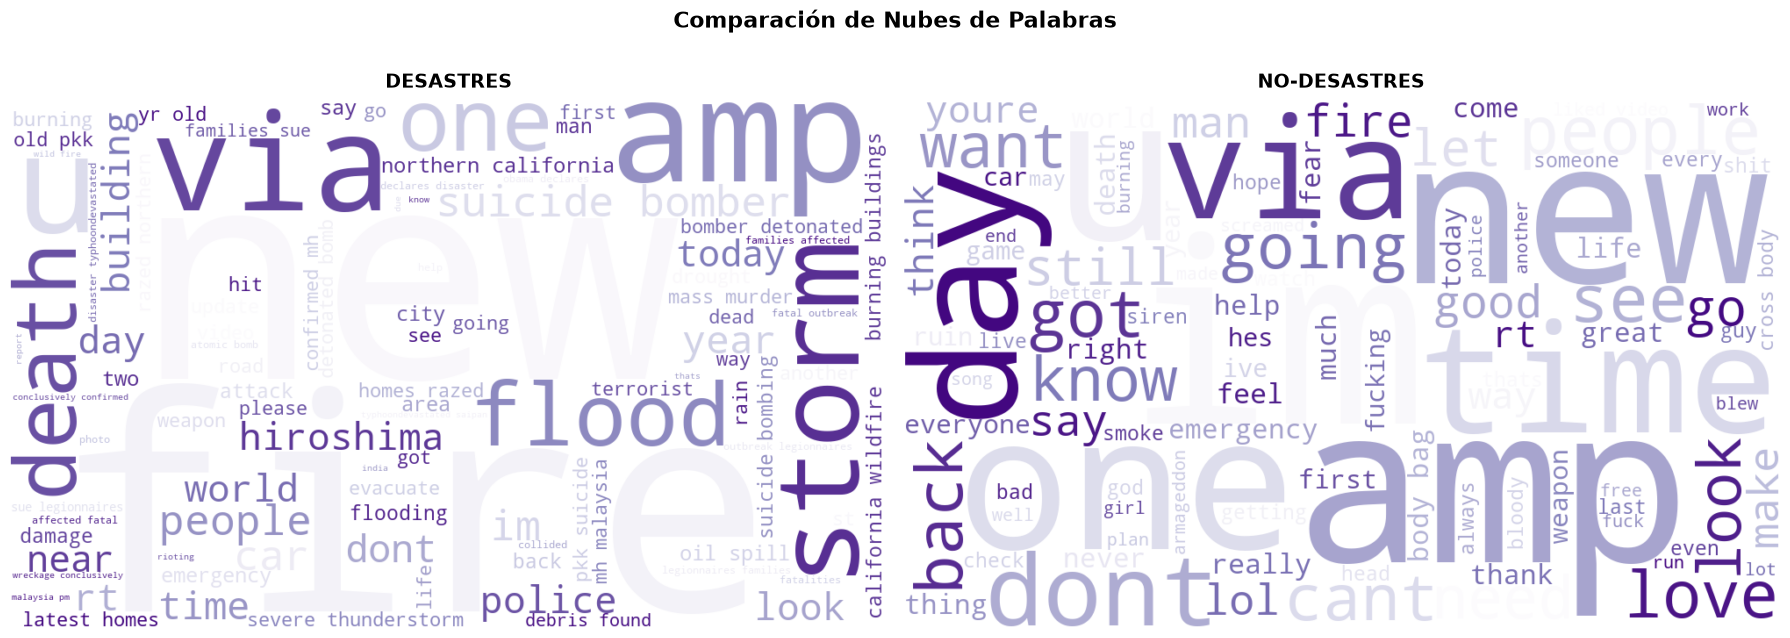

Gráfico guardado: wordcloud_comparacion.png


In [18]:
wordcloud_desastres = WordCloud(
    width=1000, height=600,
    background_color='white',
    colormap='Purples',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(texto_desastres)

wordcloud_no_desastres = WordCloud(
    width=1000, height=600,
    background_color='white',
    colormap='Purples',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(texto_no_desastres)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(wordcloud_desastres, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('DESASTRES', fontsize=14, fontweight='bold', pad=10)

axes[1].imshow(wordcloud_no_desastres, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('NO-DESASTRES', fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Comparación de Nubes de Palabras', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('wordcloud_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: wordcloud_comparacion.png")

## 12. Análisis de Palabras Compartidas vs Exclusivas

In [19]:
palabras_desastres_set = set(frecuencia_desastres.keys())
palabras_no_desastres_set = set(frecuencia_no_desastres.keys())

palabras_comunes = palabras_desastres_set & palabras_no_desastres_set
palabras_solo_desastres = palabras_desastres_set - palabras_no_desastres_set
palabras_solo_no_desastres = palabras_no_desastres_set - palabras_desastres_set

print("ANÁLISIS DE PALABRAS")
print("=" * 60)
print(f"Palabras únicas en DESASTRES: {len(palabras_desastres_set)}")
print(f"Palabras únicas en NO-DESASTRES: {len(palabras_no_desastres_set)}")
print(f"\nPalabras en AMBAS: {len(palabras_comunes)}")
print(f"Palabras SOLO en desastres: {len(palabras_solo_desastres)}")
print(f"Palabras SOLO en no-desastres: {len(palabras_solo_no_desastres)}")

print(f"\nEjemplos de palabras EXCLUSIVAS de desastres:")
print(sorted(list(palabras_solo_desastres))[:20])

print(f"\nEjemplos de palabras EXCLUSIVAS de no-desastres:")
print(sorted(list(palabras_solo_no_desastres))[:20])

ANÁLISIS DE PALABRAS
Palabras únicas en DESASTRES: 8006
Palabras únicas en NO-DESASTRES: 10372

Palabras en AMBAS: 3805
Palabras SOLO en desastres: 4201
Palabras SOLO en no-desastres: 6567

Ejemplos de palabras EXCLUSIVAS de desastres:
['aaaaaaallll', 'aaaaaand', 'aaarrrgghhh', 'aal', 'aampb', 'aan', 'aashiqui', 'abbswinston', 'abc', 'abcnews', 'abcs', 'aberystwythshrewsbury', 'abes', 'abha', 'abia', 'ableg', 'aboard', 'abomb', 'abombed', 'abouts']

Ejemplos de palabras EXCLUSIVAS de no-desastres:
['aaaa', 'aampw', 'aannnnd', 'aar', 'ab', 'abandoning', 'abbandoned', 'abbott', 'abbruchsimulator', 'abceyewitness', 'aberdeen', 'abject', 'abomination', 'abortions', 'abstract', 'absurdly', 'abused', 'academia', 'accepts', 'access']


## 13. Visualización: Palabras por Categoría

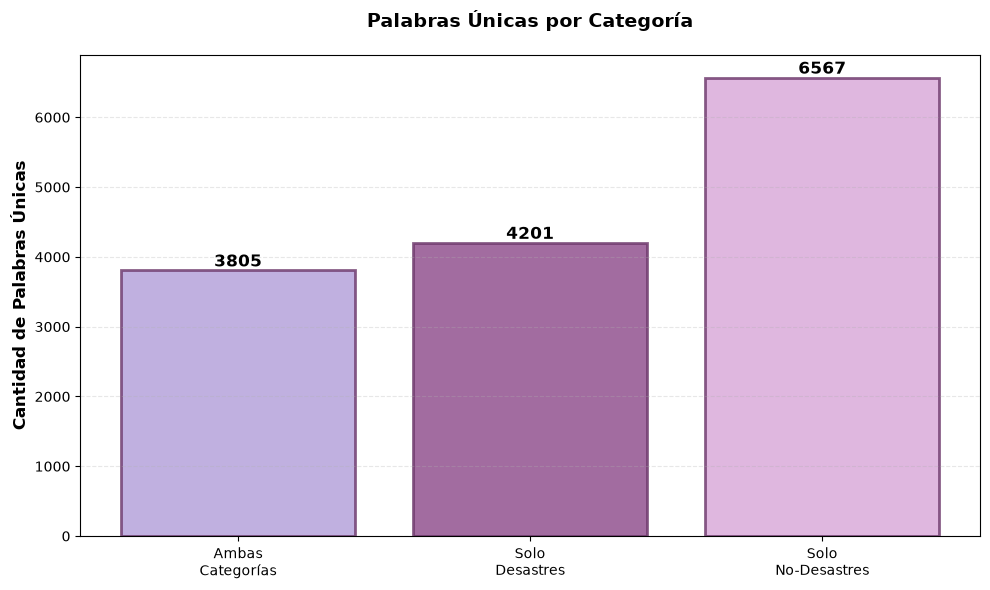

Gráfico guardado: palabras_analisis.png


In [20]:
categorias = ['Ambas\nCategorías', 'Solo\nDesastres', 'Solo\nNo-Desastres']
cantidades = [len(palabras_comunes), len(palabras_solo_desastres), len(palabras_solo_no_desastres)]
colores = ['#B19CD9', '#8B4789', '#D8A5D8']

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(categorias, cantidades, color=colores, edgecolor='#6B3569', linewidth=2, alpha=0.8)

for barra, cantidad in zip(barras, cantidades):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'{int(cantidad)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Cantidad de Palabras Únicas', fontsize=12, fontweight='bold')
ax.set_title('Palabras Únicas por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('palabras_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: palabras_analisis.png")

## 14. Conclusiones de PARTE 2A

In [23]:
print("\n" + "=" * 80)
print("RESUMEN - PARTE 2A: ANÁLISIS EXPLORATORIO Y FRECUENCIA DE PALABRAS")
print("=" * 80)

resumen = f"""
HALLAZGOS PRINCIPALES:

1. PALABRAS MAS FRECUENTES EN DESASTRES:
   - Palabras como 'fire', 'flood', 'earthquake', 'disaster' son muy frecuentes
   - Estas palabras casi no aparecen en tweets de no-desastres

2. PALABRAS MAS FRECUENTES EN NO-DESASTRES:
   - Palabras cotidianas como 'love', 'day', 'good', 'time'
   - Más variadas y menos relacionadas con eventos naturales

3. PALABRAS DISCRIMINANTES:
   - Hay {len(palabras_solo_desastres)} palabras EXCLUSIVAS de desastres
   - Hay {len(palabras_solo_no_desastres)} palabras EXCLUSIVAS de no-desastres
   - Las palabras únicas son muy útiles para clasificación

4. PALABRAS COMPARTIDAS:
   - Hay {len(palabras_comunes)} palabras que aparecen en AMBAS categorías
   - Estas palabras no distinguen bien por sí solas
   - Necesitaremos contexto (bigramas) para interpretarlas correctamente

5. NUBES DE PALABRAS:
   - Visualmente clara la diferencia entre categorías
   - Nube de desastres: dominada por términos de eventos naturales
   - Nube de no-desastres: mucho más variada y cotidiana

CONCLUSIÓN:
   Las palabras individuales (unigramas) YA DISTINGUEN BIEN entre categorías.
   Esto es un buen punto de partida para construir modelos de clasificación.

ARCHIVOS GENERADOS:
   • frecuencia_palabras_comparacion.png
   • wordcloud_comparacion.png
   • palabras_analisis.png
"""

print(resumen)



RESUMEN - PARTE 2A: ANÁLISIS EXPLORATORIO Y FRECUENCIA DE PALABRAS

HALLAZGOS PRINCIPALES:

1. PALABRAS MAS FRECUENTES EN DESASTRES:
   - Palabras como 'fire', 'flood', 'earthquake', 'disaster' son muy frecuentes
   - Estas palabras casi no aparecen en tweets de no-desastres

2. PALABRAS MAS FRECUENTES EN NO-DESASTRES:
   - Palabras cotidianas como 'love', 'day', 'good', 'time'
   - Más variadas y menos relacionadas con eventos naturales

3. PALABRAS DISCRIMINANTES:
   - Hay 4201 palabras EXCLUSIVAS de desastres
   - Hay 6567 palabras EXCLUSIVAS de no-desastres
   - Las palabras únicas son muy útiles para clasificación

4. PALABRAS COMPARTIDAS:
   - Hay 3805 palabras que aparecen en AMBAS categorías
   - Estas palabras no distinguen bien por sí solas
   - Necesitaremos contexto (bigramas) para interpretarlas correctamente

5. NUBES DE PALABRAS:
   - Visualmente clara la diferencia entre categorías
   - Nube de desastres: dominada por términos de eventos naturales
   - Nube de no-desas